<div style="font-family: 'Courier New'; font-size: 30px;">

<span style="color: lightblue; font-size: 50px;">FINAL PROJECT: LIGO Gravitational Waves Data</span>

<span style="color: lightblue;">NAME:</span> Jessica Imhauser  

<span style="color: lightblue;">COURSE:</span> PHYS 1655 Python for Scientists  

</div>

<div style="font-family: 'Courier New'; font-size: 25px;">

<span style="color: lightblue;">QUESTION:</span> How do the masses of merging black hole pairs affect the strength of gravitational wave signals detected by LIGO?


</div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Reading dataset
eventversions = pd.read_csv('event-versions_1000.csv')

# Printing shape of the dataset
print(f"Dataset shape: {eventversions.shape}")
print()

# Printing first few rows
print(eventversions.head())

# Cleaning dataset: removing rows without masses, chirpmasses or SNR
eventversions = eventversions.dropna(subset=['mass_1_source','mass_2_source', 'chirp_mass_source', 'network_matched_filter_snr'])

Dataset shape: (1000, 43)

              name           shortName           gps  version  \
0  GW160313_164009  GW160313_164009-v1  1.420878e+09        1   
1  GW230413_235659  GW230413_235659-v1  1.415278e+09        1   
2  GW250219_042034  GW250219_042034-v1  1.412725e+09        1   
3  GW230818_004421  GW230818_004421-v1  1.388812e+09        1   
4  GW170926_195507  GW170926_195507-v1  1.388626e+09        1   

               catalog                                doi  \
0  O4_Discovery_Papers  https://doi.org/10.7935/1g4j-2028   
1  O4_Discovery_Papers  https://doi.org/10.7935/46xh-t016   
2  O4_Discovery_Papers  https://doi.org/10.7935/3drz-8m81   
3             GWTC-4.0  https://doi.org/10.7935/aes8-px89   
4             GWTC-4.0  https://doi.org/10.7935/aes8-px89   

                                          detail_url  mass_1_source  \
0  https://gwosc.org/api/v2/event-versions/GW2501...           33.6   
1  https://gwosc.org/api/v2/event-versions/GW2411...           17.2   
2 

In [3]:
# Compute the median chirp mass to use as a threshold for classifying events as high or low mass
chirpmassthreshold = eventversions["chirp_mass_source"].median()

# Define the signal-to-noise ratio (SNR) threshold for classifying detections as strong or weak
SNRthreshold = 10

# Initialize counters for each category
highmass_strongsnrcount = 0
highmass_weaksnrcount = 0
lowmass_strongsnrcount = 0
lowmass_weaksnrcount = 0

# Iterate over each gravitational-wave event (row) in the dataset
for index, row in eventversions.iterrows():

    # Classify event as high-mass or low-mass based on chirp mass threshold
    if row["chirp_mass_source"] >= chirpmassthreshold:

        # Classify based on SNR strength within high-mass events
        if row["network_matched_filter_snr"] >= SNRthreshold:
            highmass_strongsnrcount += 1
        else:
            highmass_weaksnrcount += 1

    # Low-mass event classification
    else:

        # Classify based on SNR strength within low-mass events 
        if row["network_matched_filter_snr"] < SNRthreshold:
            lowmass_weaksnrcount += 1
        else:
            lowmass_strongsnrcount += 1

chart = pd.DataFrame(
    [[highmass_strongsnrcount, highmass_weaksnrcount],
    [lowmass_strongsnrcount, lowmass_weaksnrcount]],
    index = ["High Mass", "Low Mass"],
    columns = ["Strong SNR", "Weak SNR"]
    )
print(chart)

# This loop classifies each gravitational-wave event based on chirp mass (using the 
# median as a threshold to separate high-mass and low-mass systems) and signal-to-noise
# ratio (using SNR = 10 to separate strong and weak detections). The counters track how
# many of the events fall into each of four categories: high-mass strong SNR, high-mass
# weak SNR, low-mass strong SNR, low-mass weak SNR. This allows us to compare the
# detectability of gravitational wave signals across different mass domains.

           Strong SNR  Weak SNR
High Mass         236       151
Low Mass          253       117


The detection efficiency is: 60.98%
The detection efficiency is: 68.38%


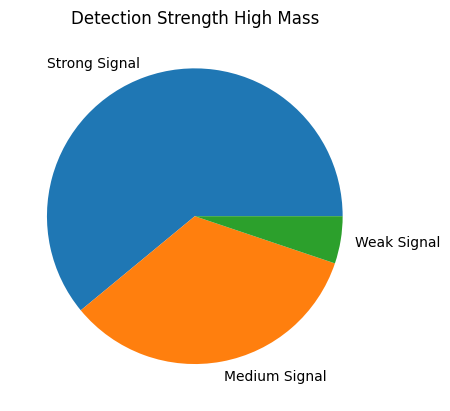

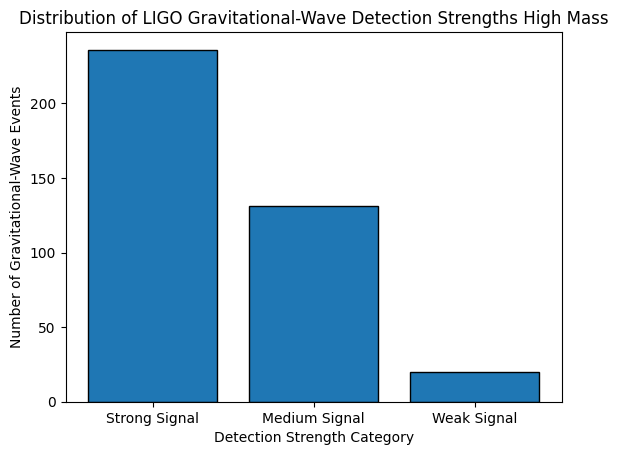

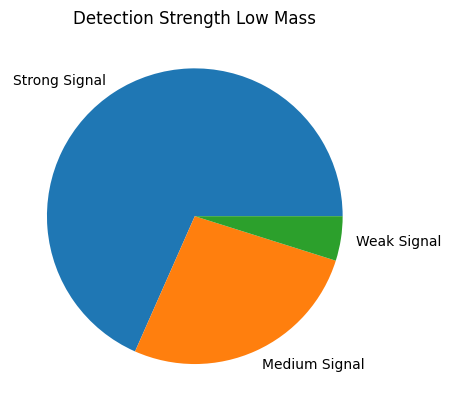

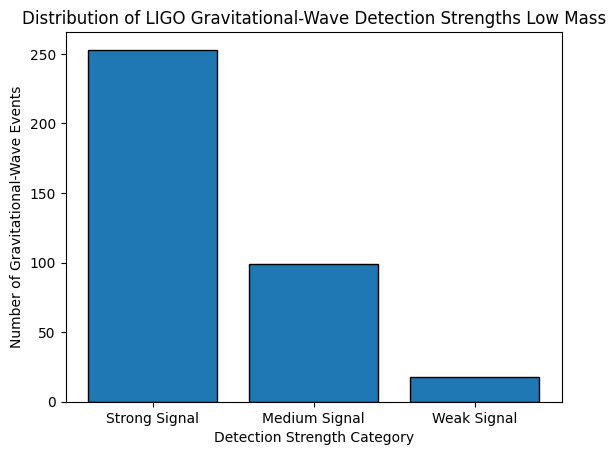

<Figure size 640x480 with 0 Axes>

In [4]:
high_mass_rows = []
low_mass_rows = []
mass_threshold = eventversions["chirp_mass_source"].median()

# Iterating over each gravitational-wave event (row) in the dataset and appending high mass and low mass rows to separate list based on mass_threshold
for index, row in eventversions.iterrows():
    if row["chirp_mass_source"] >= mass_threshold:
        high_mass_rows.append(row)
    else:
        low_mass_rows.append(row)


def compute_detection_efficiency(data, high_snr_threshold, low_snr_threshold):

    """ 
    This function takes in rows from the dataset event-versions and classified them as having a strong, medium, or weak signal based on
    the high and low thresholds passed in the argument. It then counts the number of strong, medium, and weak signals and then adds these 
    values to a dictionary called signal_catalog. It then prints the detection efficiency and number of events with a strong and weak signal.
    
    """

    # Creating a dictionary to store the number of strong, medium, and weak signals
    signal_catalog = {
        "Strong Signal": 0, "Medium Signal": 0, "Weak Signal": 0
        }
    
    # Iterating over values in passed data and computing the number of strong, medium, and weak signals
    for value in data:
        if value["network_matched_filter_snr"] >= high_snr_threshold:
            signal_catalog["Strong Signal"] += 1
        elif low_snr_threshold <= value["network_matched_filter_snr"] and value["network_matched_filter_snr"] < high_snr_threshold:
            signal_catalog["Medium Signal"] +=1
        else:
            signal_catalog["Weak Signal"] += 1
        
    # Computing the detection efficency, defined as the percentage of events with a strong signal
    detection_efficiency = signal_catalog["Strong Signal"] / len(data)
    print(f"The detection efficiency is: {(detection_efficiency * 100):.2f}%")

    # Calculating the percent of strong, medium, and weak signals
    percent_strong_signal = (signal_catalog["Strong Signal"] / len(data) * 100)
    percent_medium_signal = (signal_catalog["Medium Signal"] / len(data)) * 100
    percent_weak_signal = (signal_catalog["Weak Signal"] / len(data) * 100)
    
    # Creating a dictionary that stores pertinent data used in plot_data function to be utilized later
    plot_data_info = {
        "Signal Catalog": signal_catalog,
        "Percent Strong Signal": percent_strong_signal,
        "Percent Medium Signal": percent_medium_signal,
        "Percent Weak Signal": percent_weak_signal
        }

    return plot_data_info


high_mass_results = compute_detection_efficiency(high_mass_rows, 10, 8)
low_mass_results = compute_detection_efficiency(low_mass_rows, 10, 8)


def plot_data(plot_data_info, Label):

    # Creating each of the three categories for the pie chart
    sizes = [plot_data_info["Percent Strong Signal"], plot_data_info["Percent Medium Signal"], plot_data_info["Percent Weak Signal"]]
    labels = ['Strong Signal', 'Medium Signal', 'Weak Signal']
    
    # Plotting Each Strength Category in a Pie Chart
    plt.pie(sizes, labels = labels)
    plt.title(f"Detection Strength {Label}")
    plt.figure()

    # Plotting number of events in detection strength category
    x = []
    y = []
    for key, value in plot_data_info["Signal Catalog"].items():
        x.append(key)
        y.append(value)
    plt.xlabel("Detection Strength Category")
    plt.ylabel("Number of Gravitational-Wave Events")
    plt.title(f"Distribution of LIGO Gravitational-Wave Detection Strengths {Label}")
    plt.bar(x,y, edgecolor = 'black')
    plt.figure()

plot_data(high_mass_results, "High Mass")
plot_data(low_mass_results, "Low Mass")

# 

High-mass systems increase detectability by 2.74%
The standard deviation for high-mass events is 5.89 and the standard deviation for low-mass events is 3.99.
Therefore, high-mass systems both increase average detectability (mean SNR) and exhibit greater variability in signal strength.


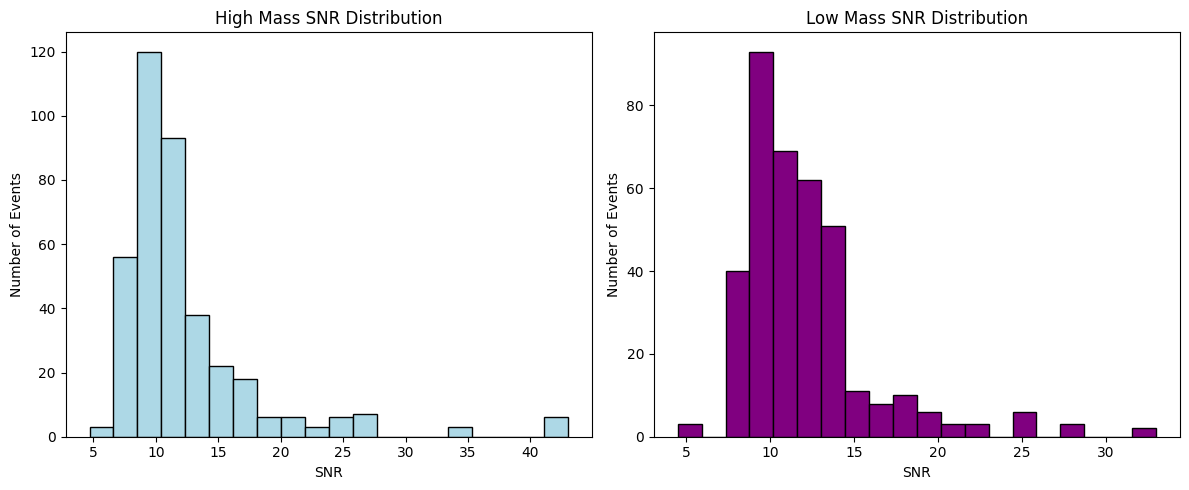

In [5]:
# SNR = signal strength relative to noise → higher means easier detection

# Transform columns of eventversions into a numpy array
m = np.array(eventversions["chirp_mass_source"])
snr = np.array(eventversions["network_matched_filter_snr"])

# Create a boolean mask condition to use to determine which snr events are high vs low mass
m_threshold = np.median(m)
high_mask = m >= m_threshold
low_mask = m < m_threshold

# Apply Boolean Mask to snr array
high_mass_snr = snr[high_mask]
low_mass_snr = snr[low_mask]

# Compute the mean snr for high and low mass events
mean_high_mass = np.mean(high_mass_snr)
mean_low_mass = np.mean(low_mass_snr)

# Compute what percentage high-mass systems increase detectability
percent_increase = ((mean_high_mass - mean_low_mass) / (mean_low_mass)) * 100
print(f"High-mass systems increase detectability by {percent_increase:.2f}%")

# Compute standard deviation for high-mass events:
std_high_mass = np.std(high_mass_snr)
std_low_mass = np.std(low_mass_snr)
print(f"The standard deviation for high-mass events is {std_high_mass:.2f} and the standard deviation for low-mass events is {std_low_mass:.2f}.")
print("Therefore, high-mass systems both increase average detectability (mean SNR) and exhibit greater variability in signal strength.")

# Creating two plots of SNR distributions side-by-side for high-mass and low-mass events
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

ax1.hist(high_mass_snr, bins=20, edgecolor='black', color='lightblue')
ax1.set_title("High Mass SNR Distribution")
ax1.set_xlabel("SNR")
ax1.set_ylabel("Number of Events")

ax2.hist(low_mass_snr, bins=20, edgecolor='black', color='purple')
ax2.set_title("Low Mass SNR Distribution")
ax2.set_xlabel("SNR")
ax2.set_ylabel("Number of Events")
plt.tight_layout()

# Both high-mass and low-mass systems have right-skewed signal-to-noise ratio (SNR) distributions,
# meaning most detections happen at moderate strength, with only a few very strong signals.
# However, high-mass systems show a longer tail on the high end. This means they are more likely
# than low mass systems to produce very high SNR detections.

In [16]:
# Extract arrays of chirp masses and snr values
true_mass = np.array(eventversions["chirp_mass_source"])
true_snr = np.array(eventversions["network_matched_filter_snr"])

# Threshold
threshold = np.median(true_mass)

# Observed Difference
true_mass_high = true_snr[true_mass >= threshold]
true_mass_low = true_snr[true_mass < threshold]
observed_difference = np.mean(true_mass_high) - np.mean(true_mass_low)

# Permutation Test
n_iterations = 1000
differences = []
for i in range(n_iterations):
    shuffled_chirp_masses = np.random.permutation(true_mass)

    high_group = true_snr[shuffled_chirp_masses >= threshold]
    low_group = true_snr[shuffled_chirp_masses < threshold]
    
    difference = np.mean(high_group) - np.mean(low_group)
    differences.append(difference)
np.array(differences)

count = np.sum(differences >= observed_difference)
p_value = count / len(differences)
print(f"The p-value is {p_value}")

The p-value is 0.186
